# Step 20 — Final Technical Synthesis

## Purpose

This notebook consolidates the validated forecasting, feature-ablation, SHAP and LSTM results into a final technical summary.

No models are trained in this notebook. All results are loaded from the validated outputs produced in earlier steps.

The synthesis has four objectives:

1. create one demand-type-specific model-performance table;
2. combine feature ablation with SHAP model-reliance evidence;
3. document the main findings and limitations consistently across experiments;
4. produce a final technical completion audit for the dissertation handoff.

A Diebold–Mariano test is not added. The experiment contains only five independent forecast origins per demand type, while each origin produces a 28-day multi-horizon forecast vector. Treating all series, dates and horizons as independent observations would overstate the available statistical evidence. Model comparisons therefore remain descriptive and are reported using validated fold-level and hierarchy-level results.

In [2]:
# Cell 1: Load and audit the validated technical outputs

from pathlib import Path

import numpy as np
import pandas as pd

CURRENT_DIRECTORY = Path.cwd().resolve()

if CURRENT_DIRECTORY.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIRECTORY.parent
else:
    PROJECT_ROOT = CURRENT_DIRECTORY

OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
)

TABLE_DIR = (
    OUTPUT_DIR
    / "tables"
)

FIGURE_DIR = (
    OUTPUT_DIR
    / "figures"
)

STEP20_TABLE_DIR = (
    TABLE_DIR
    / "step20"
)

STEP20_FIGURE_DIR = (
    FIGURE_DIR
    / "step20"
)

STEP20_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

STEP20_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

STEP16_RESULTS_FILE = (
    TABLE_DIR
    / "step16"
    / "step16_xgb_fold_results.csv"
)

STEP17_RESULTS_FILE = (
    TABLE_DIR
    / "step17"
    / "step17_ablation_results.csv"
)

STEP18_REPORT_FILE = (
    TABLE_DIR
    / "step18"
    / "step18_report_summary.csv"
)

STEP18_COMPARISON_FILE = (
    TABLE_DIR
    / "step18"
    / "step18_shap_ablation_comparison.csv"
)

STEP19_REPORT_FILE = (
    TABLE_DIR
    / "step19"
    / "step19_report_summary.csv"
)

STEP19_HIERARCHY_FILE = (
    TABLE_DIR
    / "step19"
    / "step19_hierarchy_comparison.csv"
)

required_input_files = {
    "Step 16 model results":
        STEP16_RESULTS_FILE,
    "Step 17 ablation results":
        STEP17_RESULTS_FILE,
    "Step 18 report summary":
        STEP18_REPORT_FILE,
    "Step 18 SHAP-ablation comparison":
        STEP18_COMPARISON_FILE,
    "Step 19 report summary":
        STEP19_REPORT_FILE,
    "Step 19 hierarchy comparison":
        STEP19_HIERARCHY_FILE,
}

missing_input_files = [
    input_name
    for input_name, input_path
    in required_input_files.items()
    if not input_path.exists()
]

if missing_input_files:
    raise FileNotFoundError(
        "The following validated inputs are missing:\n- "
        + "\n- ".join(
            missing_input_files
        )
    )

step16_results = pd.read_csv(
    STEP16_RESULTS_FILE
)

step17_results = pd.read_csv(
    STEP17_RESULTS_FILE
)

step18_report = pd.read_csv(
    STEP18_REPORT_FILE
)

step18_comparison = pd.read_csv(
    STEP18_COMPARISON_FILE
)

step19_report = pd.read_csv(
    STEP19_REPORT_FILE
)

step19_hierarchy = pd.read_csv(
    STEP19_HIERARCHY_FILE
)

DEMAND_TYPE_COLUMN = "demand_type"

DEMAND_TYPES = [
    "smooth",
    "erratic",
    "intermittent",
    "lumpy",
]

for dataframe in [
    step16_results,
    step17_results,
    step18_report,
    step18_comparison,
    step19_report,
    step19_hierarchy,
]:
    dataframe[
        DEMAND_TYPE_COLUMN
    ] = (
        dataframe[
            DEMAND_TYPE_COLUMN
        ].astype(str)
    )

input_checks = {
    "20 Step 16 model-result rows": (
        len(step16_results) == 20
    ),
    "Five Step 16 folds": (
        step16_results[
            "fold"
        ].nunique() == 5
    ),
    "Four Step 16 demand types": (
        set(
            step16_results[
                DEMAND_TYPE_COLUMN
            ]
        )
        == set(DEMAND_TYPES)
    ),
    "100 Step 17 ablation rows": (
        len(step17_results) == 100
    ),
    "Four Step 18 report rows": (
        len(step18_report) == 4
    ),
    "20 Step 18 comparison rows": (
        len(step18_comparison) == 20
    ),
    "Two Step 19 report rows": (
        len(step19_report) == 2
    ),
    "24 Step 19 hierarchy rows": (
        len(step19_hierarchy) == 24
    ),
    "No duplicate Step 16 groups": (
        step16_results
        .duplicated(
            subset=[
                "fold",
                DEMAND_TYPE_COLUMN,
            ]
        )
        .sum() == 0
    ),
    "No duplicate Step 17 experiments": (
        step17_results
        .duplicated(
            subset=[
                "fold",
                DEMAND_TYPE_COLUMN,
                "removed_feature_group",
            ]
        )
        .sum() == 0
    ),
    "No duplicate Step 18 comparisons": (
        step18_comparison
        .duplicated(
            subset=[
                DEMAND_TYPE_COLUMN,
                "feature_group",
            ]
        )
        .sum() == 0
    ),
    "No missing Step 16 model metrics": (
        step16_results[
            [
                "naive_wrmsse",
                "xgb_wrmsse",
                "naive_mae",
                "xgb_mae",
                "naive_rmse",
                "xgb_rmse",
            ]
        ]
        .isna()
        .sum()
        .sum() == 0
    ),
}

input_check_table = pd.DataFrame(
    {
        "check": input_checks.keys(),
        "passed": input_checks.values(),
    }
)

print("Step 20 validated inputs")
print("-" * 70)

for input_name, input_path in (
    required_input_files.items()
):
    print(
        f"{input_name}: {input_path}"
    )

print()
print("Input audit")

display(input_check_table)

failed_input_checks = [
    check
    for check, passed
    in input_checks.items()
    if not passed
]

if failed_input_checks:
    raise AssertionError(
        "Step 20 input audit failed:\n- "
        + "\n- ".join(
            failed_input_checks
        )
    )

print()
print("Step 20 input audit passed.")

Step 20 validated inputs
----------------------------------------------------------------------
Step 16 model results: C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step16\step16_xgb_fold_results.csv
Step 17 ablation results: C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step17\step17_ablation_results.csv
Step 18 report summary: C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step18\step18_report_summary.csv
Step 18 SHAP-ablation comparison: C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step18\step18_shap_ablation_comparison.csv
Step 19 report summary: C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step19\step19_report_summary.csv
Step 19 hierarchy comparison: C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step19\step19_hierarchy_comparison.csv

Input audit


,check,passed
0,20 Step 16 model-result rows,True
1,Five Step 16 folds,True
2,Four Step 16 demand types,True
3,100 Step 17 ablation rows,True
4,Four Step 18 report rows,True
5,20 Step 18 comparison rows,True
6,Two Step 19 report rows,True
7,24 Step 19 hierarchy rows,True
8,No duplicate Step 16 groups,True
9,No duplicate Step 17 experiments,True



Step 20 input audit passed.


In [3]:
# Cell 2: Create the final model-performance summary

step16_model_summary = (
    step16_results
    .groupby(
        DEMAND_TYPE_COLUMN,
        observed=True,
        as_index=False,
    )
    .agg(
        folds=(
            "fold",
            "nunique",
        ),
        mean_seasonal_naive_wrmsse=(
            "naive_wrmsse",
            "mean",
        ),
        standard_deviation_seasonal_naive_wrmsse=(
            "naive_wrmsse",
            "std",
        ),
        mean_xgb_wrmsse=(
            "xgb_wrmsse",
            "mean",
        ),
        standard_deviation_xgb_wrmsse=(
            "xgb_wrmsse",
            "std",
        ),
        mean_seasonal_naive_mae=(
            "naive_mae",
            "mean",
        ),
        mean_xgb_mae=(
            "xgb_mae",
            "mean",
        ),
        mean_seasonal_naive_rmse=(
            "naive_rmse",
            "mean",
        ),
        mean_xgb_rmse=(
            "xgb_rmse",
            "mean",
        ),
    )
)

step16_model_summary[
    "xgb_wrmsse_improvement_percentage"
] = (
    (
        step16_model_summary[
            "mean_seasonal_naive_wrmsse"
        ]
        - step16_model_summary[
            "mean_xgb_wrmsse"
        ]
    )
    / step16_model_summary[
        "mean_seasonal_naive_wrmsse"
    ]
    * 100
)

step16_model_summary[
    "xgb_mae_improvement_percentage"
] = (
    (
        step16_model_summary[
            "mean_seasonal_naive_mae"
        ]
        - step16_model_summary[
            "mean_xgb_mae"
        ]
    )
    / step16_model_summary[
        "mean_seasonal_naive_mae"
    ]
    * 100
)

step16_model_summary[
    "xgb_rmse_improvement_percentage"
] = (
    (
        step16_model_summary[
            "mean_seasonal_naive_rmse"
        ]
        - step16_model_summary[
            "mean_xgb_rmse"
        ]
    )
    / step16_model_summary[
        "mean_seasonal_naive_rmse"
    ]
    * 100
)

xgb_win_summary = (
    step16_results
    .assign(
        xgb_wrmsse_win=(
            step16_results[
                "xgb_wrmsse"
            ]
            < step16_results[
                "naive_wrmsse"
            ]
        ),
        xgb_mae_win=(
            step16_results[
                "xgb_mae"
            ]
            < step16_results[
                "naive_mae"
            ]
        ),
        xgb_rmse_win=(
            step16_results[
                "xgb_rmse"
            ]
            < step16_results[
                "naive_rmse"
            ]
        ),
    )
    .groupby(
        DEMAND_TYPE_COLUMN,
        observed=True,
        as_index=False,
    )
    .agg(
        xgb_wrmsse_wins=(
            "xgb_wrmsse_win",
            "sum",
        ),
        xgb_mae_wins=(
            "xgb_mae_win",
            "sum",
        ),
        xgb_rmse_wins=(
            "xgb_rmse_win",
            "sum",
        ),
    )
)

lstm_summary_columns = [
    DEMAND_TYPE_COLUMN,
    "mean_lstm_wrmsse",
    "mean_lstm_mae",
    "mean_lstm_rmse",
    "mean_lstm_error",
    "lstm_vs_xgb_wrmsse_percentage",
    "lstm_vs_naive_wrmsse_percentage",
    "feasibility_result",
]

missing_lstm_columns = [
    column
    for column in lstm_summary_columns
    if column not in step19_report.columns
]

if missing_lstm_columns:
    raise KeyError(
        "The Step 19 report summary is missing:\n- "
        + "\n- ".join(
            missing_lstm_columns
        )
    )

master_model_summary = (
    step16_model_summary
    .merge(
        xgb_win_summary,
        on=DEMAND_TYPE_COLUMN,
        how="left",
        validate="one_to_one",
    )
    .merge(
        step19_report[
            lstm_summary_columns
        ],
        on=DEMAND_TYPE_COLUMN,
        how="left",
        validate="one_to_one",
    )
)

master_model_summary[
    "lstm_evaluated"
] = (
    master_model_summary[
        DEMAND_TYPE_COLUMN
    ].isin(
        [
            "smooth",
            "erratic",
        ]
    )
)

master_model_summary[
    "lstm_status"
] = np.where(
    master_model_summary[
        "lstm_evaluated"
    ],
    "Evaluated as a feasibility study",
    "Not evaluated under the locked scope",
)

def identify_best_primary_model(row):
    """
    Identify the model with the lowest mean WRMSSE
    from those evaluated for the demand type.
    """

    candidate_scores = {
        "Seasonal naive": float(
            row[
                "mean_seasonal_naive_wrmsse"
            ]
        ),
        "XGBoost": float(
            row[
                "mean_xgb_wrmsse"
            ]
        ),
    }

    if (
        row["lstm_evaluated"]
        and pd.notna(
            row["mean_lstm_wrmsse"]
        )
    ):
        candidate_scores["LSTM"] = float(
            row["mean_lstm_wrmsse"]
        )

    return min(
        candidate_scores,
        key=candidate_scores.get,
    )


master_model_summary[
    "best_primary_model"
] = (
    master_model_summary.apply(
        identify_best_primary_model,
        axis=1,
    )
)

demand_order = {
    demand_type: position
    for position, demand_type
    in enumerate(DEMAND_TYPES)
}

master_model_summary[
    "demand_order"
] = (
    master_model_summary[
        DEMAND_TYPE_COLUMN
    ].map(demand_order)
)

master_model_summary = (
    master_model_summary
    .sort_values(
        "demand_order"
    )
    .drop(
        columns="demand_order"
    )
    .reset_index(drop=True)
)

evaluated_lstm_rows = (
    master_model_summary.loc[
        master_model_summary[
            "lstm_evaluated"
        ]
    ]
)

non_evaluated_lstm_rows = (
    master_model_summary.loc[
        ~master_model_summary[
            "lstm_evaluated"
        ]
    ]
)

model_summary_checks = {
    "Four demand-type rows": (
        len(master_model_summary) == 4
    ),
    "Five folds per demand type": (
        master_model_summary[
            "folds"
        ].eq(5).all()
    ),
    "All demand types represented": (
        set(
            master_model_summary[
                DEMAND_TYPE_COLUMN
            ]
        )
        == set(DEMAND_TYPES)
    ),
    "No missing seasonal-naive metrics": (
        master_model_summary[
            [
                "mean_seasonal_naive_wrmsse",
                "mean_seasonal_naive_mae",
                "mean_seasonal_naive_rmse",
            ]
        ]
        .isna()
        .sum()
        .sum() == 0
    ),
    "No missing XGBoost metrics": (
        master_model_summary[
            [
                "mean_xgb_wrmsse",
                "mean_xgb_mae",
                "mean_xgb_rmse",
            ]
        ]
        .isna()
        .sum()
        .sum() == 0
    ),
    "LSTM metrics present for evaluated types": (
        evaluated_lstm_rows[
            [
                "mean_lstm_wrmsse",
                "mean_lstm_mae",
                "mean_lstm_rmse",
                "mean_lstm_error",
            ]
        ]
        .isna()
        .sum()
        .sum() == 0
    ),
    "LSTM metrics absent for excluded types": (
        non_evaluated_lstm_rows[
            [
                "mean_lstm_wrmsse",
                "mean_lstm_mae",
                "mean_lstm_rmse",
                "mean_lstm_error",
            ]
        ]
        .isna()
        .all()
        .all()
    ),
    "XGBoost is the best primary model for all types": (
        master_model_summary[
            "best_primary_model"
        ].eq(
            "XGBoost"
        ).all()
    ),
}

model_summary_check_table = pd.DataFrame(
    {
        "check": model_summary_checks.keys(),
        "passed": model_summary_checks.values(),
    }
)

print("Master model-performance summary")
print("-" * 70)

display(
    master_model_summary.round(6)
)

print("Model-summary audit")

display(
    model_summary_check_table
)

failed_model_summary_checks = [
    check
    for check, passed
    in model_summary_checks.items()
    if not passed
]

if failed_model_summary_checks:
    raise AssertionError(
        "Master model-summary audit failed:\n- "
        + "\n- ".join(
            failed_model_summary_checks
        )
    )

STEP20_MODEL_SUMMARY_FILE = (
    STEP20_TABLE_DIR
    / "step20_master_model_summary.csv"
)

master_model_summary.to_csv(
    STEP20_MODEL_SUMMARY_FILE,
    index=False,
)

print()
print("Master model-performance summary passed.")
print("Saved:")
print(STEP20_MODEL_SUMMARY_FILE)

Master model-performance summary
----------------------------------------------------------------------


,demand_type,folds,mean_seasonal_naive_wrmsse,standard_deviation_seasonal_naive_wrmsse,mean_xgb_wrmsse,standard_deviation_xgb_wrmsse,mean_seasonal_naive_mae,mean_xgb_mae,mean_seasonal_naive_rmse,mean_xgb_rmse,...,mean_lstm_wrmsse,mean_lstm_mae,mean_lstm_rmse,mean_lstm_error,lstm_vs_xgb_wrmsse_percentage,lstm_vs_naive_wrmsse_percentage,feasibility_result,lstm_evaluated,lstm_status,best_primary_model
0,smooth,5,0.806369,0.092384,0.635986,0.075556,3.335036,2.595579,5.355817,4.214855,...,0.92777,2.738940,4.558170,-1.096112,45.879062,15.055246,LSTM did not improve WRMSSE,True,Evaluated as a feasibility study,XGBoost
1,erratic,5,0.949980,0.160334,0.793776,0.159467,4.450500,3.530675,7.194735,5.663739,...,1.25133,3.549202,6.123754,-1.680902,57.642792,31.721678,LSTM did not improve WRMSSE,True,Evaluated as a feasibility study,XGBoost
2,intermittent,5,1.215647,0.236160,1.209538,0.229088,0.893964,0.755978,2.165976,1.909097,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Not evaluated under the locked scope,XGBoost
3,lumpy,5,1.258928,0.066524,1.127514,0.272143,1.766929,1.451802,3.390620,2.687967,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Not evaluated under the locked scope,XGBoost


Model-summary audit


,check,passed
0,Four demand-type rows,True
1,Five folds per demand type,True
2,All demand types represented,True
3,No missing seasonal-naive metrics,True
4,No missing XGBoost metrics,True
5,LSTM metrics present for evaluated types,True
6,LSTM metrics absent for excluded types,True
7,XGBoost is the best primary model for all types,True



Master model-performance summary passed.
Saved:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step20\step20_master_model_summary.csv


In [4]:
# Cell 3: Combine Step 17 ablation and Step 18 SHAP evidence

print("Creating the master feature-evidence table")
print("-" * 70)

recalculated_ablation_summary = (
    step17_results
    .groupby(
        [
            DEMAND_TYPE_COLUMN,
            "removed_feature_group",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        folds=(
            "fold",
            "nunique",
        ),
        recalculated_mean_delta_wrmsse=(
            "delta_wrmsse",
            "mean",
        ),
        recalculated_median_delta_wrmsse=(
            "delta_wrmsse",
            "median",
        ),
        folds_removal_worsened_recalculated=(
            "delta_wrmsse",
            lambda values: int(
                (values > 0).sum()
            ),
        ),
        folds_removal_improved_recalculated=(
            "delta_wrmsse",
            lambda values: int(
                (values < 0).sum()
            ),
        ),
    )
    .rename(
        columns={
            "removed_feature_group":
                "feature_group"
        }
    )
)

master_feature_evidence = (
    step18_comparison
    .merge(
        recalculated_ablation_summary,
        on=[
            DEMAND_TYPE_COLUMN,
            "feature_group",
        ],
        how="left",
        validate="one_to_one",
    )
)

master_feature_evidence[
    "ablation_reproduction_difference"
] = (
    master_feature_evidence[
        "mean_delta_wrmsse"
    ]
    - master_feature_evidence[
        "recalculated_mean_delta_wrmsse"
    ]
)

feature_output_columns = [
    DEMAND_TYPE_COLUMN,
    "feature_group",
    "mean_importance_percentage",
    "importance_rank",
    "mean_delta_wrmsse",
    "change_from_mean_scores_percentage",
    "folds_removal_worsened",
    "folds_removal_improved",
    "comparison_pattern",
    "fold_consistency",
    "minimum_delta_wrmsse",
    "maximum_delta_wrmsse",
    "standard_deviation_delta_wrmsse",
    "ablation_reproduction_difference",
]

missing_feature_output_columns = [
    column
    for column in feature_output_columns
    if column not in (
        master_feature_evidence.columns
    )
]

if missing_feature_output_columns:
    raise KeyError(
        "The feature-evidence table is missing:\n- "
        + "\n- ".join(
            missing_feature_output_columns
        )
    )

master_feature_evidence = (
    master_feature_evidence[
        feature_output_columns
    ]
    .copy()
)

master_feature_evidence[
    "demand_order"
] = (
    master_feature_evidence[
        DEMAND_TYPE_COLUMN
    ].map(demand_order)
)

master_feature_evidence = (
    master_feature_evidence
    .sort_values(
        [
            "demand_order",
            "importance_rank",
            "feature_group",
        ]
    )
    .drop(
        columns="demand_order"
    )
    .reset_index(drop=True)
)

maximum_ablation_reproduction_difference = float(
    master_feature_evidence[
        "ablation_reproduction_difference"
    ]
    .abs()
    .max()
)

importance_share_sums = (
    master_feature_evidence
    .groupby(
        DEMAND_TYPE_COLUMN,
        observed=True,
    )[
        "mean_importance_percentage"
    ]
    .sum()
)

feature_evidence_checks = {
    "20 feature-evidence rows": (
        len(master_feature_evidence) == 20
    ),
    "Five groups per demand type": (
        master_feature_evidence
        .groupby(
            DEMAND_TYPE_COLUMN,
            observed=True,
        )["feature_group"]
        .nunique()
        .eq(5)
        .all()
    ),
    "Four demand types represented": (
        set(
            master_feature_evidence[
                DEMAND_TYPE_COLUMN
            ]
        )
        == set(DEMAND_TYPES)
    ),
    "Five folds in every comparison": (
        (
            master_feature_evidence[
                "folds_removal_worsened"
            ]
            + master_feature_evidence[
                "folds_removal_improved"
            ]
        )
        .le(5)
        .all()
    ),
    "Step 17 mean deltas reproduced within 1e-12": (
        maximum_ablation_reproduction_difference
        < 1e-12
    ),
    "SHAP shares sum to 100 percent per type": (
        np.allclose(
            importance_share_sums.to_numpy(
                dtype=np.float64
            ),
            100.0,
            rtol=1e-10,
            atol=1e-8,
        )
    ),
    "No missing feature-evidence values": (
        master_feature_evidence
        .isna()
        .sum()
        .sum() == 0
    ),
    "All importance percentages valid": (
        master_feature_evidence[
            "mean_importance_percentage"
        ].between(
            0,
            100,
            inclusive="both",
        ).all()
    ),
}

feature_evidence_check_table = pd.DataFrame(
    {
        "check": feature_evidence_checks.keys(),
        "passed": feature_evidence_checks.values(),
    }
)

print("Master feature-evidence table")

display(
    master_feature_evidence.round(6)
)

print("Feature-evidence audit")

display(
    feature_evidence_check_table
)

print(
    "Maximum Step 17 reproduction difference:",
    f"{maximum_ablation_reproduction_difference:.12e}",
)

failed_feature_evidence_checks = [
    check
    for check, passed
    in feature_evidence_checks.items()
    if not passed
]

if failed_feature_evidence_checks:
    raise AssertionError(
        "Master feature-evidence audit failed:\n- "
        + "\n- ".join(
            failed_feature_evidence_checks
        )
    )

STEP20_FEATURE_EVIDENCE_FILE = (
    STEP20_TABLE_DIR
    / "step20_master_feature_evidence.csv"
)

master_feature_evidence.to_csv(
    STEP20_FEATURE_EVIDENCE_FILE,
    index=False,
)

print()
print("Master feature-evidence table passed.")
print("Saved:")
print(STEP20_FEATURE_EVIDENCE_FILE)

Creating the master feature-evidence table
----------------------------------------------------------------------
Master feature-evidence table


,demand_type,feature_group,mean_importance_percentage,importance_rank,mean_delta_wrmsse,change_from_mean_scores_percentage,folds_removal_worsened,folds_removal_improved,comparison_pattern,fold_consistency,minimum_delta_wrmsse,maximum_delta_wrmsse,standard_deviation_delta_wrmsse,ablation_reproduction_difference
0,smooth,rolling,69.708188,1,-0.001118,-0.175816,3,2,High model reliance but negative mean ablation...,Mixed fold-level direction,-0.014735,0.007847,0.010005,0.0
1,smooth,calendar,12.944642,2,0.125891,19.794560,5,0,High model reliance and positive mean ablation...,Removal worsened WRMSSE in all five folds,0.092569,0.153140,0.023737,-0.0
2,smooth,lag,9.093213,3,0.026797,4.213475,4,1,Lower model reliance and positive mean ablatio...,Removal usually worsened WRMSSE,-0.036461,0.085538,0.046054,-0.0
3,smooth,event_snap,4.982042,4,0.006075,0.955285,2,3,Lower model reliance and positive mean ablatio...,Mixed fold-level direction,-0.042611,0.059463,0.041361,-0.0
4,smooth,price,3.271915,5,-0.007923,-1.245839,2,3,Lower model reliance and negative mean ablatio...,Mixed fold-level direction,-0.056338,0.013285,0.028152,0.0
5,erratic,rolling,66.267293,1,0.007874,0.991934,2,3,High model reliance and positive mean ablation...,Mixed fold-level direction,-0.059233,0.096579,0.058632,-0.0
6,erratic,calendar,15.935115,2,0.113205,14.261553,4,1,High model reliance and positive mean ablation...,Removal usually worsened WRMSSE,-0.000036,0.288517,0.113464,-0.0
7,erratic,lag,8.614833,3,0.018197,2.292507,3,2,Lower model reliance and positive mean ablatio...,Mixed fold-level direction,-0.010018,0.055534,0.026075,-0.0
8,erratic,event_snap,5.465850,4,-0.004004,-0.504452,2,3,Lower model reliance and negative mean ablatio...,Mixed fold-level direction,-0.048797,0.052912,0.036962,0.0
9,erratic,price,3.716909,5,0.004197,0.528743,3,2,Lower model reliance and positive mean ablatio...,Mixed fold-level direction,-0.020980,0.031202,0.019105,-0.0


Feature-evidence audit


,check,passed
0,20 feature-evidence rows,True
1,Five groups per demand type,True
2,Four demand types represented,True
3,Five folds in every comparison,True
4,Step 17 mean deltas reproduced within 1e-12,True
5,SHAP shares sum to 100 percent per type,True
6,No missing feature-evidence values,True
7,All importance percentages valid,True


Maximum Step 17 reproduction difference: 9.714451465470e-17

Master feature-evidence table passed.
Saved:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step20\step20_master_feature_evidence.csv


In [5]:
# Cell 4: Create the integrated demand-type findings table

print("Creating the integrated demand-type findings")
print("-" * 70)

required_step18_report_columns = [
    DEMAND_TYPE_COLUMN,
    "top_feature_group",
    "top_group_mean_share_percentage",
    "top_feature",
    "top_feature_mean_share_percentage",
    "largest_positive_ablation_group",
    "largest_positive_mean_delta_wrmsse",
    "largest_negative_ablation_group",
    "largest_negative_mean_delta_wrmsse",
]

missing_step18_report_columns = [
    column
    for column in required_step18_report_columns
    if column not in step18_report.columns
]

if missing_step18_report_columns:
    raise KeyError(
        "The Step 18 report summary is missing:\n- "
        + "\n- ".join(
            missing_step18_report_columns
        )
    )

integrated_findings = (
    master_model_summary[
        [
            DEMAND_TYPE_COLUMN,
            "mean_seasonal_naive_wrmsse",
            "mean_xgb_wrmsse",
            "xgb_wrmsse_improvement_percentage",
            "xgb_wrmsse_wins",
            "mean_seasonal_naive_mae",
            "mean_xgb_mae",
            "mean_seasonal_naive_rmse",
            "mean_xgb_rmse",
            "best_primary_model",
            "lstm_evaluated",
            "lstm_status",
            "mean_lstm_wrmsse",
            "lstm_vs_xgb_wrmsse_percentage",
            "lstm_vs_naive_wrmsse_percentage",
            "feasibility_result",
        ]
    ]
    .merge(
        step18_report[
            required_step18_report_columns
        ],
        on=DEMAND_TYPE_COLUMN,
        how="left",
        validate="one_to_one",
    )
)

integrated_findings[
    "lstm_result"
] = np.where(
    integrated_findings[
        "lstm_evaluated"
    ],
    integrated_findings[
        "feasibility_result"
    ],
    "Not evaluated under the locked scope",
)

integrated_findings[
    "primary_model_finding"
] = (
    integrated_findings.apply(
        lambda row: (
            f"XGBoost reduced mean WRMSSE by "
            f"{row['xgb_wrmsse_improvement_percentage']:.3f}% "
            f"relative to seasonal naive and won "
            f"{int(row['xgb_wrmsse_wins'])} of 5 folds."
        ),
        axis=1,
    )
)

integrated_findings[
    "feature_finding"
] = (
    integrated_findings.apply(
        lambda row: (
            f"{row['top_feature_group']} features accounted for "
            f"{row['top_group_mean_share_percentage']:.3f}% "
            f"of mean SHAP reliance. "
            f"The strongest positive mean ablation effect came "
            f"from {row['largest_positive_ablation_group']} "
            f"(ΔWRMSSE "
            f"{row['largest_positive_mean_delta_wrmsse']:.6f})."
        ),
        axis=1,
    )
)

integrated_findings[
    "caution_finding"
] = (
    integrated_findings.apply(
        lambda row: (
            f"Removing {row['largest_negative_ablation_group']} "
            f"produced the most negative mean ΔWRMSSE "
            f"({row['largest_negative_mean_delta_wrmsse']:.6f}); "
            f"therefore SHAP reliance must not be interpreted "
            f"as forecast benefit."
        ),
        axis=1,
    )
)

integrated_findings[
    "demand_order"
] = (
    integrated_findings[
        DEMAND_TYPE_COLUMN
    ].map(demand_order)
)

integrated_findings = (
    integrated_findings
    .sort_values(
        "demand_order"
    )
    .drop(
        columns=[
            "demand_order",
            "feasibility_result",
        ]
    )
    .reset_index(drop=True)
)

integrated_checks = {
    "Four integrated finding rows": (
        len(integrated_findings) == 4
    ),
    "All demand types represented": (
        set(
            integrated_findings[
                DEMAND_TYPE_COLUMN
            ]
        )
        == set(DEMAND_TYPES)
    ),
    "XGBoost recorded as best model": (
        integrated_findings[
            "best_primary_model"
        ].eq(
            "XGBoost"
        ).all()
    ),
    "Top feature group available for every type": (
        integrated_findings[
            "top_feature_group"
        ].notna().all()
    ),
    "Top feature available for every type": (
        integrated_findings[
            "top_feature"
        ].notna().all()
    ),
    "Primary findings completed": (
        integrated_findings[
            "primary_model_finding"
        ].str.len().gt(0).all()
    ),
    "Feature findings completed": (
        integrated_findings[
            "feature_finding"
        ].str.len().gt(0).all()
    ),
    "Caution findings completed": (
        integrated_findings[
            "caution_finding"
        ].str.len().gt(0).all()
    ),
    "LSTM result completed for every type": (
        integrated_findings[
            "lstm_result"
        ].notna().all()
    ),
}

integrated_check_table = pd.DataFrame(
    {
        "check": integrated_checks.keys(),
        "passed": integrated_checks.values(),
    }
)

print("Integrated demand-type findings")

display(
    integrated_findings.round(6)
)

print("Integrated-findings audit")

display(
    integrated_check_table
)

failed_integrated_checks = [
    check
    for check, passed
    in integrated_checks.items()
    if not passed
]

if failed_integrated_checks:
    raise AssertionError(
        "Integrated-findings audit failed:\n- "
        + "\n- ".join(
            failed_integrated_checks
        )
    )

STEP20_INTEGRATED_FINDINGS_FILE = (
    STEP20_TABLE_DIR
    / "step20_integrated_findings.csv"
)

integrated_findings.to_csv(
    STEP20_INTEGRATED_FINDINGS_FILE,
    index=False,
)

print()
print("Integrated demand-type findings passed.")
print("Saved:")
print(STEP20_INTEGRATED_FINDINGS_FILE)

Creating the integrated demand-type findings
----------------------------------------------------------------------
Integrated demand-type findings


,demand_type,mean_seasonal_naive_wrmsse,mean_xgb_wrmsse,xgb_wrmsse_improvement_percentage,xgb_wrmsse_wins,mean_seasonal_naive_mae,mean_xgb_mae,mean_seasonal_naive_rmse,mean_xgb_rmse,best_primary_model,...,top_feature,top_feature_mean_share_percentage,largest_positive_ablation_group,largest_positive_mean_delta_wrmsse,largest_negative_ablation_group,largest_negative_mean_delta_wrmsse,lstm_result,primary_model_finding,feature_finding,caution_finding
0,smooth,0.806369,0.635986,21.129705,5,3.335036,2.595579,5.355817,4.214855,XGBoost,...,rolling_mean_7,45.960579,calendar,0.125891,price,-0.007923,LSTM did not improve WRMSSE,XGBoost reduced mean WRMSSE by 21.130% relativ...,rolling features accounted for 69.708% of mean...,Removing price produced the most negative mean...
1,erratic,0.949980,0.793776,16.442943,5,4.450500,3.530675,7.194735,5.663739,XGBoost,...,rolling_mean_7,43.434899,calendar,0.113205,event_snap,-0.004004,LSTM did not improve WRMSSE,XGBoost reduced mean WRMSSE by 16.443% relativ...,rolling features accounted for 66.267% of mean...,Removing event_snap produced the most negative...
2,intermittent,1.215647,1.209538,0.502542,4,0.893964,0.755978,2.165976,1.909097,XGBoost,...,rolling_mean_28,30.042448,price,0.026657,lag,-0.073589,Not evaluated under the locked scope,XGBoost reduced mean WRMSSE by 0.503% relative...,rolling features accounted for 70.840% of mean...,Removing lag produced the most negative mean Δ...
3,lumpy,1.258928,1.127514,10.438578,4,1.766929,1.451802,3.390620,2.687967,XGBoost,...,rolling_mean_7,35.597307,price,0.094992,rolling,-0.047435,Not evaluated under the locked scope,XGBoost reduced mean WRMSSE by 10.439% relativ...,rolling features accounted for 72.190% of mean...,Removing rolling produced the most negative me...


Integrated-findings audit


,check,passed
0,Four integrated finding rows,True
1,All demand types represented,True
2,XGBoost recorded as best model,True
3,Top feature group available for every type,True
4,Top feature available for every type,True
5,Primary findings completed,True
6,Feature findings completed,True
7,Caution findings completed,True
8,LSTM result completed for every type,True



Integrated demand-type findings passed.
Saved:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step20\step20_integrated_findings.csv


In [6]:
# Cell 5: Create the final methodological-limitations table

print("Creating the final methodological-limitations table")
print("-" * 70)

methodological_limitations = pd.DataFrame(
    [
        {
            "area": "Balanced modelling subset",
            "limitation": (
                "The modelling experiment used 200 series from each "
                "demand type. This enabled equal cross-type comparison "
                "but did not preserve the natural M5 distribution, where "
                "intermittent and lumpy demand represented 95.156% of series."
            ),
            "reporting_rule": (
                "Interpret comparisons as results from a balanced "
                "experimental design rather than population-level M5 estimates."
            ),
        },
        {
            "area": "Subset WRMSSE",
            "limitation": (
                "The 12-level hierarchy and weights were rebuilt separately "
                "for each 200-series demand-type subset."
            ),
            "reporting_rule": (
                "Do not compare the scores directly with the official "
                "full-M5 competition leaderboard."
            ),
        },
        {
            "area": "Forecast-origin count",
            "limitation": (
                "Each demand type contained only five independent "
                "walk-forward forecast origins."
            ),
            "reporting_rule": (
                "Treat fold comparisons as descriptive and do not claim "
                "statistical significance."
            ),
        },
        {
            "area": "Diebold–Mariano test",
            "limitation": (
                "The experiment produced multi-horizon forecasts from only "
                "five origins per demand type. Treating individual series, "
                "dates or horizons as independent observations would "
                "overstate the effective sample size."
            ),
            "reporting_rule": (
                "Omit the test and report insufficient independent "
                "forecast origins as the reason."
            ),
        },
        {
            "area": "Feature ablation",
            "limitation": (
                "Ablated models used the Step 16 round counts and were not "
                "retuned after removing a feature group."
            ),
            "reporting_rule": (
                "Interpret ΔWRMSSE as conditional evidence under the locked "
                "training configuration, not independent or causal importance."
            ),
        },
        {
            "area": "SHAP interpretation",
            "limitation": (
                "SHAP measured how the fitted XGBoost models relied on "
                "features on the output-margin scale."
            ),
            "reporting_rule": (
                "Do not interpret high SHAP importance as forecast benefit, "
                "causality or statistical significance."
            ),
        },
        {
            "area": "LSTM comparison",
            "limitation": (
                "The LSTM used only 56 historical sales values, while "
                "XGBoost used lag, rolling, calendar, event, SNAP and "
                "price features."
            ),
            "reporting_rule": (
                "Present the LSTM as a sequence-only feasibility study, "
                "not a controlled architecture comparison."
            ),
        },
        {
            "area": "LSTM demand-type scope",
            "limitation": (
                "The LSTM experiment covered smooth and erratic demand only."
            ),
            "reporting_rule": (
                "Do not infer LSTM performance for intermittent or "
                "lumpy demand."
            ),
        },
        {
            "area": "Missing price values",
            "limitation": (
                "Price missingness was concentrated in intermittent and "
                "lumpy demand and was retained rather than filled."
            ),
            "reporting_rule": (
                "Describe this as a modelling decision based on likely "
                "product absence from sale, not confirmed stock status."
            ),
        },
        {
            "area": "External regressors",
            "limitation": (
                "Weather and search-trend regressors were excluded from "
                "the final locked scope."
            ),
            "reporting_rule": (
                "Do not imply that external regressors were tested or that "
                "their usefulness was established."
            ),
        },
    ]
)

limitation_checks = {
    "Ten methodological limitations": (
        len(methodological_limitations) == 10
    ),
    "No missing limitation values": (
        methodological_limitations
        .isna()
        .sum()
        .sum() == 0
    ),
    "All areas unique": (
        methodological_limitations[
            "area"
        ].nunique()
        == len(methodological_limitations)
    ),
    "All limitation descriptions completed": (
        methodological_limitations[
            "limitation"
        ].str.len().gt(0).all()
    ),
    "All reporting rules completed": (
        methodological_limitations[
            "reporting_rule"
        ].str.len().gt(0).all()
    ),
    "DM omission documented": (
        methodological_limitations[
            "area"
        ].eq(
            "Diebold–Mariano test"
        ).any()
    ),
    "Non-retuned ablation documented": (
        methodological_limitations[
            "area"
        ].eq(
            "Feature ablation"
        ).any()
    ),
    "LSTM information difference documented": (
        methodological_limitations[
            "area"
        ].eq(
            "LSTM comparison"
        ).any()
    ),
}

limitation_check_table = pd.DataFrame(
    {
        "check": limitation_checks.keys(),
        "passed": limitation_checks.values(),
    }
)

display(
    methodological_limitations
)

print("Methodological-limitations audit")

display(
    limitation_check_table
)

failed_limitation_checks = [
    check
    for check, passed
    in limitation_checks.items()
    if not passed
]

if failed_limitation_checks:
    raise AssertionError(
        "Methodological-limitations audit failed:\n- "
        + "\n- ".join(
            failed_limitation_checks
        )
    )

STEP20_LIMITATIONS_FILE = (
    STEP20_TABLE_DIR
    / "step20_methodological_limitations.csv"
)

methodological_limitations.to_csv(
    STEP20_LIMITATIONS_FILE,
    index=False,
)

print()
print("Methodological-limitations table passed.")
print("Saved:")
print(STEP20_LIMITATIONS_FILE)

Creating the final methodological-limitations table
----------------------------------------------------------------------


,area,limitation,reporting_rule
0,Balanced modelling subset,The modelling experiment used 200 series from ...,Interpret comparisons as results from a balanc...
1,Subset WRMSSE,The 12-level hierarchy and weights were rebuil...,Do not compare the scores directly with the of...
2,Forecast-origin count,Each demand type contained only five independe...,Treat fold comparisons as descriptive and do n...
3,Diebold–Mariano test,The experiment produced multi-horizon forecast...,Omit the test and report insufficient independ...
4,Feature ablation,Ablated models used the Step 16 round counts a...,Interpret ΔWRMSSE as conditional evidence unde...
5,SHAP interpretation,SHAP measured how the fitted XGBoost models re...,Do not interpret high SHAP importance as forec...
6,LSTM comparison,"The LSTM used only 56 historical sales values,...",Present the LSTM as a sequence-only feasibilit...
7,LSTM demand-type scope,The LSTM experiment covered smooth and erratic...,Do not infer LSTM performance for intermittent...
8,Missing price values,Price missingness was concentrated in intermit...,Describe this as a modelling decision based on...
9,External regressors,Weather and search-trend regressors were exclu...,Do not imply that external regressors were tes...


Methodological-limitations audit


,check,passed
0,Ten methodological limitations,True
1,No missing limitation values,True
2,All areas unique,True
3,All limitation descriptions completed,True
4,All reporting rules completed,True
5,DM omission documented,True
6,Non-retuned ablation documented,True
7,LSTM information difference documented,True



Methodological-limitations table passed.
Saved:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step20\step20_methodological_limitations.csv


## Final Model-Performance Comparison

The figure reports the mean WRMSSE across five walk-forward folds. Lower values indicate better hierarchical forecasting performance. LSTM results are shown only for smooth and erratic demand because those were the two demand types included in the feasibility study.

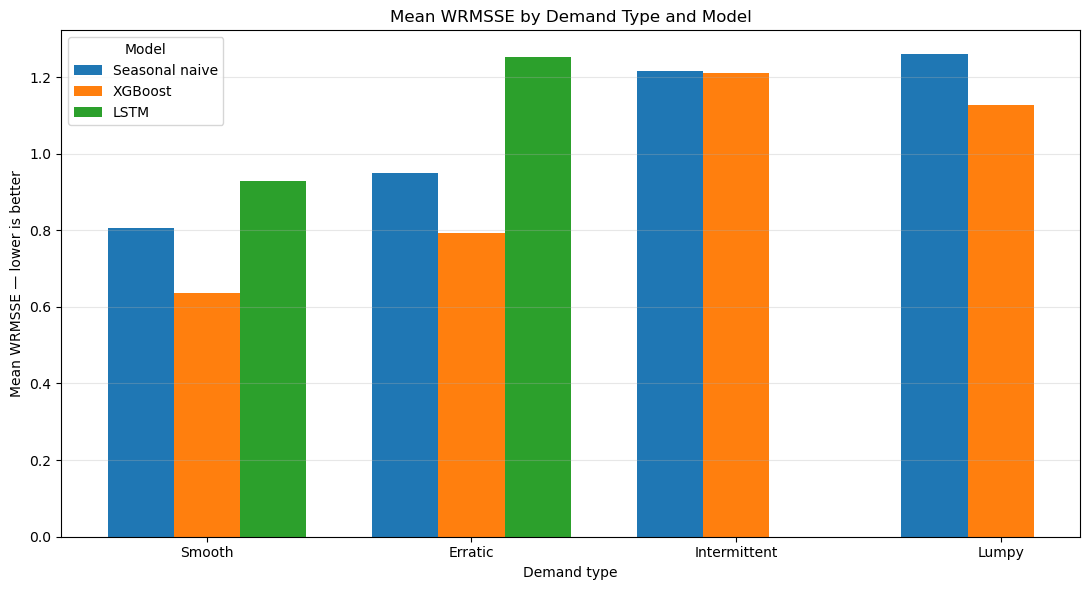

,check,passed
0,Final model figure exists,True
1,Final model figure non-empty,True
2,Four demand types plotted,True
3,Two LSTM demand types plotted,True



Final model-performance figure passed.
Saved:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\figures\step20\step20_final_model_performance.png


In [7]:
# Cell 6: Plot the final mean WRMSSE comparison

import matplotlib.pyplot as plt

plot_demand_types = DEMAND_TYPES

plot_positions = np.arange(
    len(plot_demand_types)
)

bar_width = 0.25

plot_table = (
    master_model_summary
    .set_index(
        DEMAND_TYPE_COLUMN
    )
    .reindex(
        plot_demand_types
    )
)

figure, axis = plt.subplots(
    figsize=(11, 6)
)

axis.bar(
    plot_positions - bar_width,
    plot_table[
        "mean_seasonal_naive_wrmsse"
    ],
    width=bar_width,
    label="Seasonal naive",
)

axis.bar(
    plot_positions,
    plot_table[
        "mean_xgb_wrmsse"
    ],
    width=bar_width,
    label="XGBoost",
)

lstm_values = (
    plot_table[
        "mean_lstm_wrmsse"
    ].to_numpy(
        dtype=np.float64
    )
)

lstm_available = np.isfinite(
    lstm_values
)

axis.bar(
    plot_positions[
        lstm_available
    ]
    + bar_width,
    lstm_values[
        lstm_available
    ],
    width=bar_width,
    label="LSTM",
)

axis.set_title(
    "Mean WRMSSE by Demand Type and Model"
)

axis.set_xlabel(
    "Demand type"
)

axis.set_ylabel(
    "Mean WRMSSE — lower is better"
)

axis.set_xticks(
    plot_positions
)

axis.set_xticklabels(
    [
        demand_type.capitalize()
        for demand_type
        in plot_demand_types
    ]
)

axis.legend(
    title="Model"
)

axis.grid(
    axis="y",
    alpha=0.3,
)

figure.tight_layout()

STEP20_MODEL_FIGURE_FILE = (
    STEP20_FIGURE_DIR
    / "step20_final_model_performance.png"
)

figure.savefig(
    STEP20_MODEL_FIGURE_FILE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

figure_checks = {
    "Final model figure exists": (
        STEP20_MODEL_FIGURE_FILE.exists()
    ),
    "Final model figure non-empty": (
        STEP20_MODEL_FIGURE_FILE.exists()
        and STEP20_MODEL_FIGURE_FILE
        .stat()
        .st_size > 0
    ),
    "Four demand types plotted": (
        len(plot_positions) == 4
    ),
    "Two LSTM demand types plotted": (
        int(
            lstm_available.sum()
        ) == 2
    ),
}

figure_check_table = pd.DataFrame(
    {
        "check": figure_checks.keys(),
        "passed": figure_checks.values(),
    }
)

display(
    figure_check_table
)

failed_figure_checks = [
    check
    for check, passed
    in figure_checks.items()
    if not passed
]

if failed_figure_checks:
    raise AssertionError(
        "Step 20 model figure failed:\n- "
        + "\n- ".join(
            failed_figure_checks
        )
    )

print()
print("Final model-performance figure passed.")
print("Saved:")
print(STEP20_MODEL_FIGURE_FILE)

In [8]:
# Cell 7: Create the final report-ready synthesis tables

print("Creating the final Step 20 report-ready tables")
print("-" * 70)

# ---------------------------------------------------------
# Report-ready model-performance table
# ---------------------------------------------------------

report_model_columns = [
    DEMAND_TYPE_COLUMN,
    "folds",
    "mean_seasonal_naive_wrmsse",
    "mean_xgb_wrmsse",
    "xgb_wrmsse_improvement_percentage",
    "xgb_wrmsse_wins",
    "mean_seasonal_naive_mae",
    "mean_xgb_mae",
    "mean_seasonal_naive_rmse",
    "mean_xgb_rmse",
    "mean_lstm_wrmsse",
    "mean_lstm_mae",
    "mean_lstm_rmse",
    "mean_lstm_error",
    "lstm_vs_xgb_wrmsse_percentage",
    "lstm_vs_naive_wrmsse_percentage",
    "lstm_evaluated",
    "lstm_status",
    "best_primary_model",
]

missing_report_model_columns = [
    column
    for column in report_model_columns
    if column not in master_model_summary.columns
]

if missing_report_model_columns:
    raise KeyError(
        "The master model summary is missing:\n- "
        + "\n- ".join(
            missing_report_model_columns
        )
    )

step20_report_model_summary = (
    master_model_summary[
        report_model_columns
    ]
    .copy()
    .reset_index(drop=True)
)

step20_report_model_summary[
    "lstm_conclusion"
] = np.where(
    step20_report_model_summary[
        "lstm_evaluated"
    ],
    "LSTM did not improve WRMSSE",
    "Not evaluated under the locked scope",
)

# ---------------------------------------------------------
# Report-ready feature-evidence table
# ---------------------------------------------------------

report_feature_columns = [
    DEMAND_TYPE_COLUMN,
    "top_feature_group",
    "top_group_mean_share_percentage",
    "top_feature",
    "top_feature_mean_share_percentage",
    "largest_positive_ablation_group",
    "largest_positive_mean_delta_wrmsse",
    "largest_negative_ablation_group",
    "largest_negative_mean_delta_wrmsse",
]

missing_report_feature_columns = [
    column
    for column in report_feature_columns
    if column not in integrated_findings.columns
]

if missing_report_feature_columns:
    raise KeyError(
        "The integrated findings are missing:\n- "
        + "\n- ".join(
            missing_report_feature_columns
        )
    )

step20_report_feature_summary = (
    integrated_findings[
        report_feature_columns
    ]
    .copy()
    .rename(
        columns={
            "largest_positive_ablation_group":
                "strongest_positive_ablation_group",
            "largest_positive_mean_delta_wrmsse":
                "strongest_positive_mean_delta_wrmsse",
            "largest_negative_ablation_group":
                "strongest_negative_ablation_group",
            "largest_negative_mean_delta_wrmsse":
                "strongest_negative_mean_delta_wrmsse",
        }
    )
    .reset_index(drop=True)
)

lstm_numeric_columns = [
    "mean_lstm_wrmsse",
    "mean_lstm_mae",
    "mean_lstm_rmse",
    "mean_lstm_error",
    "lstm_vs_xgb_wrmsse_percentage",
    "lstm_vs_naive_wrmsse_percentage",
]

evaluated_report_rows = (
    step20_report_model_summary.loc[
        step20_report_model_summary[
            "lstm_evaluated"
        ]
    ]
)

excluded_report_rows = (
    step20_report_model_summary.loc[
        ~step20_report_model_summary[
            "lstm_evaluated"
        ]
    ]
)

report_table_checks = {
    "Four model-summary rows": (
        len(step20_report_model_summary) == 4
    ),
    "Four feature-summary rows": (
        len(step20_report_feature_summary) == 4
    ),
    "All demand types in model table": (
        set(
            step20_report_model_summary[
                DEMAND_TYPE_COLUMN
            ]
        )
        == set(DEMAND_TYPES)
    ),
    "All demand types in feature table": (
        set(
            step20_report_feature_summary[
                DEMAND_TYPE_COLUMN
            ]
        )
        == set(DEMAND_TYPES)
    ),
    "Five folds per model-summary row": (
        step20_report_model_summary[
            "folds"
        ].eq(5).all()
    ),
    "XGBoost is best for all demand types": (
        step20_report_model_summary[
            "best_primary_model"
        ].eq("XGBoost").all()
    ),
    "LSTM metrics present for evaluated types": (
        evaluated_report_rows[
            lstm_numeric_columns
        ]
        .notna()
        .all()
        .all()
    ),
    "LSTM metrics absent for excluded types": (
        excluded_report_rows[
            lstm_numeric_columns
        ]
        .isna()
        .all()
        .all()
    ),
    "LSTM conclusions completed": (
        step20_report_model_summary[
            "lstm_conclusion"
        ]
        .notna()
        .all()
    ),
    "No missing feature-summary values": (
        step20_report_feature_summary
        .isna()
        .sum()
        .sum() == 0
    ),
}

report_table_check_table = pd.DataFrame(
    {
        "check": report_table_checks.keys(),
        "passed": report_table_checks.values(),
    }
)

print("Report-ready model summary")

display(
    step20_report_model_summary.round(6)
)

print("Report-ready feature summary")

display(
    step20_report_feature_summary.round(6)
)

print("Report-table audit")

display(
    report_table_check_table
)

failed_report_table_checks = [
    check
    for check, passed
    in report_table_checks.items()
    if not passed
]

if failed_report_table_checks:
    raise AssertionError(
        "Step 20 report-table audit failed:\n- "
        + "\n- ".join(
            failed_report_table_checks
        )
    )

STEP20_REPORT_MODEL_FILE = (
    STEP20_TABLE_DIR
    / "step20_report_model_summary.csv"
)

STEP20_REPORT_FEATURE_FILE = (
    STEP20_TABLE_DIR
    / "step20_report_feature_summary.csv"
)

step20_report_model_summary.to_csv(
    STEP20_REPORT_MODEL_FILE,
    index=False,
)

step20_report_feature_summary.to_csv(
    STEP20_REPORT_FEATURE_FILE,
    index=False,
)

print()
print("Step 20 report-ready tables passed.")
print("Saved:")
print(STEP20_REPORT_MODEL_FILE)
print(STEP20_REPORT_FEATURE_FILE)

Creating the final Step 20 report-ready tables
----------------------------------------------------------------------
Report-ready model summary


,demand_type,folds,mean_seasonal_naive_wrmsse,mean_xgb_wrmsse,xgb_wrmsse_improvement_percentage,xgb_wrmsse_wins,mean_seasonal_naive_mae,mean_xgb_mae,mean_seasonal_naive_rmse,mean_xgb_rmse,mean_lstm_wrmsse,mean_lstm_mae,mean_lstm_rmse,mean_lstm_error,lstm_vs_xgb_wrmsse_percentage,lstm_vs_naive_wrmsse_percentage,lstm_evaluated,lstm_status,best_primary_model,lstm_conclusion
0,smooth,5,0.806369,0.635986,21.129705,5,3.335036,2.595579,5.355817,4.214855,0.92777,2.738940,4.558170,-1.096112,45.879062,15.055246,True,Evaluated as a feasibility study,XGBoost,LSTM did not improve WRMSSE
1,erratic,5,0.949980,0.793776,16.442943,5,4.450500,3.530675,7.194735,5.663739,1.25133,3.549202,6.123754,-1.680902,57.642792,31.721678,True,Evaluated as a feasibility study,XGBoost,LSTM did not improve WRMSSE
2,intermittent,5,1.215647,1.209538,0.502542,4,0.893964,0.755978,2.165976,1.909097,NaN,NaN,NaN,NaN,NaN,NaN,False,Not evaluated under the locked scope,XGBoost,Not evaluated under the locked scope
3,lumpy,5,1.258928,1.127514,10.438578,4,1.766929,1.451802,3.390620,2.687967,NaN,NaN,NaN,NaN,NaN,NaN,False,Not evaluated under the locked scope,XGBoost,Not evaluated under the locked scope


Report-ready feature summary


,demand_type,top_feature_group,top_group_mean_share_percentage,top_feature,top_feature_mean_share_percentage,strongest_positive_ablation_group,strongest_positive_mean_delta_wrmsse,strongest_negative_ablation_group,strongest_negative_mean_delta_wrmsse
0,smooth,rolling,69.708188,rolling_mean_7,45.960579,calendar,0.125891,price,-0.007923
1,erratic,rolling,66.267293,rolling_mean_7,43.434899,calendar,0.113205,event_snap,-0.004004
2,intermittent,rolling,70.839853,rolling_mean_28,30.042448,price,0.026657,lag,-0.073589
3,lumpy,rolling,72.189930,rolling_mean_7,35.597307,price,0.094992,rolling,-0.047435


Report-table audit


,check,passed
0,Four model-summary rows,True
1,Four feature-summary rows,True
2,All demand types in model table,True
3,All demand types in feature table,True
4,Five folds per model-summary row,True
5,XGBoost is best for all demand types,True
6,LSTM metrics present for evaluated types,True
7,LSTM metrics absent for excluded types,True
8,LSTM conclusions completed,True
9,No missing feature-summary values,True



Step 20 report-ready tables passed.
Saved:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step20\step20_report_model_summary.csv
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step20\step20_report_feature_summary.csv


In [9]:
# Cell 8: Create the final technical conclusions table

print("Creating the final technical conclusions")
print("-" * 70)

model_lookup = (
    master_model_summary
    .set_index(
        DEMAND_TYPE_COLUMN
    )
)

feature_lookup = (
    master_feature_evidence
    .set_index(
        [
            DEMAND_TYPE_COLUMN,
            "feature_group",
        ]
    )
)

smooth_hierarchy_level_1 = (
    step19_hierarchy.loc[
        (
            step19_hierarchy[
                DEMAND_TYPE_COLUMN
            ] == "smooth"
        )
        & (
            step19_hierarchy[
                "level"
            ] == 1
        )
    ]
    .iloc[0]
)

smooth_hierarchy_level_12 = (
    step19_hierarchy.loc[
        (
            step19_hierarchy[
                DEMAND_TYPE_COLUMN
            ] == "smooth"
        )
        & (
            step19_hierarchy[
                "level"
            ] == 12
        )
    ]
    .iloc[0]
)

erratic_hierarchy_level_1 = (
    step19_hierarchy.loc[
        (
            step19_hierarchy[
                DEMAND_TYPE_COLUMN
            ] == "erratic"
        )
        & (
            step19_hierarchy[
                "level"
            ] == 1
        )
    ]
    .iloc[0]
)

erratic_hierarchy_level_12 = (
    step19_hierarchy.loc[
        (
            step19_hierarchy[
                DEMAND_TYPE_COLUMN
            ] == "erratic"
        )
        & (
            step19_hierarchy[
                "level"
            ] == 12
        )
    ]
    .iloc[0]
)

final_technical_conclusions = pd.DataFrame(
    [
        {
            "finding_id": 1,
            "topic": "Demand heterogeneity",
            "conclusion": (
                "XGBoost performance gains differed substantially "
                "between demand types."
            ),
            "numerical_evidence": (
                "Mean WRMSSE improvements over seasonal naive were "
                f"{model_lookup.loc['smooth', 'xgb_wrmsse_improvement_percentage']:.3f}% "
                "for smooth, "
                f"{model_lookup.loc['erratic', 'xgb_wrmsse_improvement_percentage']:.3f}% "
                "for erratic, "
                f"{model_lookup.loc['intermittent', 'xgb_wrmsse_improvement_percentage']:.3f}% "
                "for intermittent and "
                f"{model_lookup.loc['lumpy', 'xgb_wrmsse_improvement_percentage']:.3f}% "
                "for lumpy demand."
            ),
            "reporting_caution": (
                "Report results separately by demand type rather "
                "than presenting one universal model effect."
            ),
        },
        {
            "finding_id": 2,
            "topic": "Primary model",
            "conclusion": (
                "XGBoost was the strongest primary forecasting "
                "model under the evaluated design."
            ),
            "numerical_evidence": (
                "XGBoost produced the lowest mean WRMSSE for all "
                "four demand types and beat seasonal naive in "
                "5 of 5 smooth folds, 5 of 5 erratic folds, "
                "4 of 5 intermittent folds and 4 of 5 lumpy folds."
            ),
            "reporting_caution": (
                "Do not describe the fold counts as evidence of "
                "statistical significance."
            ),
        },
        {
            "finding_id": 3,
            "topic": "Intermittent demand",
            "conclusion": (
                "XGBoost provided only a small WRMSSE improvement "
                "for intermittent demand."
            ),
            "numerical_evidence": (
                "Mean WRMSSE decreased from "
                f"{model_lookup.loc['intermittent', 'mean_seasonal_naive_wrmsse']:.6f} "
                "to "
                f"{model_lookup.loc['intermittent', 'mean_xgb_wrmsse']:.6f}, "
                "an improvement of "
                f"{model_lookup.loc['intermittent', 'xgb_wrmsse_improvement_percentage']:.3f}%."
            ),
            "reporting_caution": (
                "Do not generalise the stronger smooth and erratic "
                "results to intermittent demand."
            ),
        },
        {
            "finding_id": 4,
            "topic": "SHAP reliance",
            "conclusion": (
                "Rolling features dominated complete-model SHAP "
                "reliance for every demand type."
            ),
            "numerical_evidence": (
                "Mean rolling-group SHAP shares were "
                f"{feature_lookup.loc[('smooth', 'rolling'), 'mean_importance_percentage']:.3f}% "
                "for smooth, "
                f"{feature_lookup.loc[('erratic', 'rolling'), 'mean_importance_percentage']:.3f}% "
                "for erratic, "
                f"{feature_lookup.loc[('intermittent', 'rolling'), 'mean_importance_percentage']:.3f}% "
                "for intermittent and "
                f"{feature_lookup.loc[('lumpy', 'rolling'), 'mean_importance_percentage']:.3f}% "
                "for lumpy demand."
            ),
            "reporting_caution": (
                "SHAP measures model reliance and does not establish "
                "forecast benefit or causality."
            ),
        },
        {
            "finding_id": 5,
            "topic": "Calendar features",
            "conclusion": (
                "Calendar features provided the clearest positive "
                "ablation evidence for smooth and erratic demand."
            ),
            "numerical_evidence": (
                "Removing calendar features increased mean WRMSSE by "
                f"{feature_lookup.loc[('smooth', 'calendar'), 'mean_delta_wrmsse']:.6f} "
                "for smooth and "
                f"{feature_lookup.loc[('erratic', 'calendar'), 'mean_delta_wrmsse']:.6f} "
                "for erratic demand."
            ),
            "reporting_caution": (
                "Ablation values are conditional on the locked "
                "non-retuned model configuration."
            ),
        },
        {
            "finding_id": 6,
            "topic": "Intermittent feature evidence",
            "conclusion": (
                "Lag and event/SNAP feature groups did not improve "
                "mean intermittent-demand WRMSSE under the locked setup."
            ),
            "numerical_evidence": (
                "Removing lag features improved WRMSSE in all five "
                "folds with mean ΔWRMSSE "
                f"{feature_lookup.loc[('intermittent', 'lag'), 'mean_delta_wrmsse']:.6f}. "
                "Removing event/SNAP features improved four of five "
                "folds with mean ΔWRMSSE "
                f"{feature_lookup.loc[('intermittent', 'event_snap'), 'mean_delta_wrmsse']:.6f}."
            ),
            "reporting_caution": (
                "Do not interpret this as proof that these variables "
                "are inherently unhelpful for intermittent demand."
            ),
        },
        {
            "finding_id": 7,
            "topic": "Lumpy feature evidence",
            "conclusion": (
                "Price and event/SNAP information provided the most "
                "consistent positive ablation evidence for lumpy demand."
            ),
            "numerical_evidence": (
                "Removing price increased mean WRMSSE by "
                f"{feature_lookup.loc[('lumpy', 'price'), 'mean_delta_wrmsse']:.6f}, "
                "and removing event/SNAP increased it by "
                f"{feature_lookup.loc[('lumpy', 'event_snap'), 'mean_delta_wrmsse']:.6f}. "
                "Both removals worsened all five folds."
            ),
            "reporting_caution": (
                "These are conditional predictive contributions, "
                "not causal effects."
            ),
        },
        {
            "finding_id": 8,
            "topic": "LSTM feasibility",
            "conclusion": (
                "The sequence-only LSTM did not improve hierarchical "
                "forecast performance."
            ),
            "numerical_evidence": (
                "LSTM mean WRMSSE was "
                f"{model_lookup.loc['smooth', 'mean_lstm_wrmsse']:.6f} "
                "for smooth and "
                f"{model_lookup.loc['erratic', 'mean_lstm_wrmsse']:.6f} "
                "for erratic demand, which was "
                f"{model_lookup.loc['smooth', 'lstm_vs_xgb_wrmsse_percentage']:.3f}% "
                "and "
                f"{model_lookup.loc['erratic', 'lstm_vs_xgb_wrmsse_percentage']:.3f}% "
                "worse than XGBoost respectively."
            ),
            "reporting_caution": (
                "The LSTM and XGBoost used different information "
                "sets, so this is not an isolated architecture comparison."
            ),
        },
        {
            "finding_id": 9,
            "topic": "Hierarchy aggregation",
            "conclusion": (
                "The LSTM disadvantage was substantially greater "
                "at aggregate hierarchy levels."
            ),
            "numerical_evidence": (
                "Relative to XGBoost, LSTM level-normalised WRMSSE "
                "was "
                f"{smooth_hierarchy_level_1['lstm_vs_xgb_level_percentage']:.3f}% "
                "worse at smooth Level 1 and "
                f"{smooth_hierarchy_level_12['lstm_vs_xgb_level_percentage']:.3f}% "
                "worse at Level 12. The corresponding erratic gaps "
                "were "
                f"{erratic_hierarchy_level_1['lstm_vs_xgb_level_percentage']:.3f}% "
                "and "
                f"{erratic_hierarchy_level_12['lstm_vs_xgb_level_percentage']:.3f}%."
            ),
            "reporting_caution": (
                "Describe the aggregation pattern without making "
                "a causal claim about why it occurred."
            ),
        },
    ]
)

conclusion_checks = {
    "Nine final technical findings": (
        len(final_technical_conclusions) == 9
    ),
    "Finding identifiers unique": (
        final_technical_conclusions[
            "finding_id"
        ].nunique() == 9
    ),
    "Topics unique": (
        final_technical_conclusions[
            "topic"
        ].nunique() == 9
    ),
    "No missing conclusion values": (
        final_technical_conclusions
        .isna()
        .sum()
        .sum() == 0
    ),
    "All conclusions completed": (
        final_technical_conclusions[
            "conclusion"
        ].str.len().gt(0).all()
    ),
    "All numerical evidence completed": (
        final_technical_conclusions[
            "numerical_evidence"
        ].str.len().gt(0).all()
    ),
    "All reporting cautions completed": (
        final_technical_conclusions[
            "reporting_caution"
        ].str.len().gt(0).all()
    ),
}

conclusion_check_table = pd.DataFrame(
    {
        "check": conclusion_checks.keys(),
        "passed": conclusion_checks.values(),
    }
)

display(
    final_technical_conclusions
)

print("Final-conclusions audit")

display(
    conclusion_check_table
)

failed_conclusion_checks = [
    check
    for check, passed
    in conclusion_checks.items()
    if not passed
]

if failed_conclusion_checks:
    raise AssertionError(
        "Final-conclusions audit failed:\n- "
        + "\n- ".join(
            failed_conclusion_checks
        )
    )

STEP20_CONCLUSIONS_FILE = (
    STEP20_TABLE_DIR
    / "step20_final_technical_conclusions.csv"
)

final_technical_conclusions.to_csv(
    STEP20_CONCLUSIONS_FILE,
    index=False,
)

print()
print("Final technical conclusions passed.")
print("Saved:")
print(STEP20_CONCLUSIONS_FILE)

Creating the final technical conclusions
----------------------------------------------------------------------


,finding_id,topic,conclusion,numerical_evidence,reporting_caution
0,1,Demand heterogeneity,XGBoost performance gains differed substantial...,Mean WRMSSE improvements over seasonal naive w...,Report results separately by demand type rathe...
1,2,Primary model,XGBoost was the strongest primary forecasting ...,XGBoost produced the lowest mean WRMSSE for al...,Do not describe the fold counts as evidence of...
2,3,Intermittent demand,XGBoost provided only a small WRMSSE improveme...,Mean WRMSSE decreased from 1.215647 to 1.20953...,Do not generalise the stronger smooth and erra...
3,4,SHAP reliance,Rolling features dominated complete-model SHAP...,Mean rolling-group SHAP shares were 69.708% fo...,SHAP measures model reliance and does not esta...
4,5,Calendar features,Calendar features provided the clearest positi...,Removing calendar features increased mean WRMS...,Ablation values are conditional on the locked ...
5,6,Intermittent feature evidence,Lag and event/SNAP feature groups did not impr...,Removing lag features improved WRMSSE in all f...,Do not interpret this as proof that these vari...
6,7,Lumpy feature evidence,Price and event/SNAP information provided the ...,Removing price increased mean WRMSSE by 0.0949...,These are conditional predictive contributions...
7,8,LSTM feasibility,The sequence-only LSTM did not improve hierarc...,LSTM mean WRMSSE was 0.927770 for smooth and 1...,The LSTM and XGBoost used different informatio...
8,9,Hierarchy aggregation,The LSTM disadvantage was substantially greate...,"Relative to XGBoost, LSTM level-normalised WRM...",Describe the aggregation pattern without makin...


Final-conclusions audit


,check,passed
0,Nine final technical findings,True
1,Finding identifiers unique,True
2,Topics unique,True
3,No missing conclusion values,True
4,All conclusions completed,True
5,All numerical evidence completed,True
6,All reporting cautions completed,True



Final technical conclusions passed.
Saved:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step20\step20_final_technical_conclusions.csv


## Step 20 Interpretation Log

| Finding | Numerical evidence | Interpretation |
|---|---|---|
| Forecast performance differed substantially by demand type. | XGBoost improved mean WRMSSE over seasonal naive by 21.130% for smooth, 16.443% for erratic, 0.503% for intermittent and 10.439% for lumpy demand. | Demand heterogeneity materially changed the practical value obtained from the same modelling framework. |
| XGBoost was the best primary model for every demand type. | XGBoost produced the lowest mean WRMSSE for all four demand types and beat seasonal naive in 18 of 20 fold-level comparisons. | The engineered-feature XGBoost model was the strongest forecasting system under the evaluated design. |
| The intermittent-demand improvement was limited. | Mean intermittent WRMSSE decreased from 1.215647 to 1.209538. | Strong performance for smooth and erratic demand should not be generalised to intermittent demand. |
| Rolling features dominated XGBoost model reliance. | Rolling-group SHAP shares ranged from 66.267% for erratic to 72.190% for lumpy demand. | Recent demand summaries formed the main basis of the fitted XGBoost predictions. |
| SHAP reliance and ablation benefit were not equivalent. | Rolling features ranked first by SHAP for all four demand types, but their mean ablation effect was negative for smooth, intermittent and lumpy demand. | A feature group can be heavily used by a fitted model without improving its mean out-of-sample WRMSSE. |
| Calendar features were especially valuable for smooth and erratic demand. | Removing calendar features increased mean WRMSSE by 0.125891 for smooth and 0.113205 for erratic demand. | Calendar information provided the clearest positive conditional feature evidence for these two demand types. |
| Lumpy demand depended more on price and event/SNAP information. | Removing price increased mean WRMSSE by 0.094992 and removing event/SNAP increased it by 0.075897; both worsened all five lumpy folds. | Feature usefulness changed with the underlying demand pattern. |
| The sequence-only LSTM was not competitive on the primary metric. | LSTM was 45.879% worse than XGBoost for smooth demand and 57.643% worse for erratic demand on mean WRMSSE. | Historical sales sequences alone were insufficient to outperform the engineered-feature XGBoost system under this feasibility design. |
| Statistical conclusions remain descriptive. | Only five independent forecast origins were available for each demand type. | Results should be presented using fold-level consistency and effect size without statistical-significance claims. |

## Step 20 Surprise Log

| Unexpected result | Numerical evidence | Treatment |
|---|---|---|
| XGBoost provided almost no mean WRMSSE improvement for intermittent demand despite reducing MAE and RMSE. | WRMSSE improved by only 0.503%, while MAE decreased from 0.893964 to 0.755978 and RMSE decreased from 2.165976 to 1.909097. | Explain that bottom-level average errors and weighted hierarchical performance measure different aspects of forecast quality. |
| Rolling features were dominant in SHAP but were not consistently beneficial in ablation. | Rolling SHAP shares exceeded 66% for all four demand types, while mean rolling-group ΔWRMSSE was negative for smooth, intermittent and lumpy demand. | Keep SHAP reliance and ablation performance conceptually separate. |
| Removing intermittent lag features improved every fold. | Mean ΔWRMSSE was -0.073589 and removal improved all five folds. | Report this honestly while retaining the non-retuning limitation. |
| Low-SHAP lumpy feature groups produced strong ablation value. | Price and event/SNAP SHAP shares were 5.502% and 4.161%, but their removal worsened all five folds. | Use this result to show why global reliance rankings cannot replace direct performance testing. |
| The LSTM beat seasonal naive on bottom-level MAE and RMSE but lost on WRMSSE in every fold. | LSTM improved both secondary metrics in all ten folds but won no WRMSSE comparison. | Emphasise the hierarchy-sensitive primary metric rather than selecting only favourable secondary results. |
| LSTM underforecasting became more damaging after aggregation. | All ten LSTM mean errors were negative, and its disadvantage was largest at Level 1. | Discuss systematic bias and aggregation descriptively without claiming a causal mechanism. |

In [10]:
# Cell 11: Run the final Step 20 completion audit

import json
import platform
import sys

print("Running the final Step 20 completion audit")
print("-" * 70)

STEP20_CONFIGURATION_FILE = (
    STEP20_TABLE_DIR
    / "step20_configuration.json"
)

step20_configuration = {
    "purpose": (
        "Consolidate validated forecasting, ablation, "
        "SHAP and LSTM results"
    ),
    "models_retrained": False,
    "demand_types": DEMAND_TYPES,
    "primary_metric": "WRMSSE",
    "secondary_metrics": [
        "MAE",
        "RMSE",
    ],
    "validated_steps": [
        16,
        17,
        18,
        19,
    ],
    "primary_model_result": (
        "XGBoost produced the lowest mean WRMSSE "
        "for all four demand types"
    ),
    "lstm_scope": [
        "smooth",
        "erratic",
    ],
    "lstm_result": (
        "LSTM did not improve WRMSSE"
    ),
    "statistical_testing": {
        "diebold_mariano_test": "Omitted",
        "reason": (
            "Only five independent multi-horizon "
            "forecast origins per demand type"
        ),
    },
    "interpretation_rules": [
        "Report every result separately by demand type",
        "Do not interpret SHAP as forecast benefit or causality",
        "Treat ablation as conditional under non-retuned settings",
        "Do not claim statistical significance",
        "Do not compare subset WRMSSE with the official M5 leaderboard",
        "Present LSTM as a sequence-only feasibility study",
    ],
    "software": {
        "python_version": sys.version,
        "platform": platform.platform(),
        "pandas_version": pd.__version__,
        "numpy_version": np.__version__,
    },
}

with open(
    STEP20_CONFIGURATION_FILE,
    "w",
    encoding="utf-8",
) as configuration_file:
    json.dump(
        step20_configuration,
        configuration_file,
        indent=2,
    )

required_step20_outputs = {
    "Master model summary": (
        STEP20_TABLE_DIR
        / "step20_master_model_summary.csv"
    ),
    "Master feature evidence": (
        STEP20_TABLE_DIR
        / "step20_master_feature_evidence.csv"
    ),
    "Integrated findings": (
        STEP20_TABLE_DIR
        / "step20_integrated_findings.csv"
    ),
    "Methodological limitations": (
        STEP20_TABLE_DIR
        / "step20_methodological_limitations.csv"
    ),
    "Report model summary": (
        STEP20_TABLE_DIR
        / "step20_report_model_summary.csv"
    ),
    "Report feature summary": (
        STEP20_TABLE_DIR
        / "step20_report_feature_summary.csv"
    ),
    "Final technical conclusions": (
        STEP20_TABLE_DIR
        / "step20_final_technical_conclusions.csv"
    ),
    "Final model figure": (
        STEP20_FIGURE_DIR
        / "step20_final_model_performance.png"
    ),
    "Configuration": (
        STEP20_CONFIGURATION_FILE
    ),
}

missing_step20_outputs = [
    output_name
    for output_name, output_path
    in required_step20_outputs.items()
    if not output_path.exists()
]

empty_step20_outputs = [
    output_name
    for output_name, output_path
    in required_step20_outputs.items()
    if (
        output_path.exists()
        and output_path.stat().st_size == 0
    )
]

partial_step20_files = sorted(
    list(
        STEP20_TABLE_DIR.glob(
            "*partial*"
        )
    )
    + list(
        STEP20_FIGURE_DIR.glob(
            "*partial*"
        )
    )
)

audit_master_model = pd.read_csv(
    required_step20_outputs[
        "Master model summary"
    ]
)

audit_master_features = pd.read_csv(
    required_step20_outputs[
        "Master feature evidence"
    ]
)

audit_integrated_findings = pd.read_csv(
    required_step20_outputs[
        "Integrated findings"
    ]
)

audit_limitations = pd.read_csv(
    required_step20_outputs[
        "Methodological limitations"
    ]
)

audit_report_model = pd.read_csv(
    required_step20_outputs[
        "Report model summary"
    ]
)

audit_report_features = pd.read_csv(
    required_step20_outputs[
        "Report feature summary"
    ]
)

audit_conclusions = pd.read_csv(
    required_step20_outputs[
        "Final technical conclusions"
    ]
)

audit_share_sums = (
    audit_master_features
    .groupby(
        DEMAND_TYPE_COLUMN,
        observed=True,
    )[
        "mean_importance_percentage"
    ]
    .sum()
)

maximum_saved_ablation_difference = float(
    audit_master_features[
        "ablation_reproduction_difference"
    ]
    .abs()
    .max()
)

prior_audit_tables = {
    "Input audit": input_check_table,
    "Model-summary audit":
        model_summary_check_table,
    "Feature-evidence audit":
        feature_evidence_check_table,
    "Integrated-findings audit":
        integrated_check_table,
    "Limitations audit":
        limitation_check_table,
    "Figure audit":
        figure_check_table,
    "Report-table audit":
        report_table_check_table,
    "Conclusions audit":
        conclusion_check_table,
}

prior_audits_passed = all(
    audit_table[
        "passed"
    ].astype(bool).all()
    for audit_table
    in prior_audit_tables.values()
)

completion_checks = {
    "All prior Step 20 audits passed": (
        prior_audits_passed
    ),
    "Four master model rows": (
        len(audit_master_model) == 4
    ),
    "Five folds per master model row": (
        audit_master_model[
            "folds"
        ].eq(5).all()
    ),
    "XGBoost best for all demand types": (
        audit_master_model[
            "best_primary_model"
        ].eq("XGBoost").all()
    ),
    "20 master feature rows": (
        len(audit_master_features) == 20
    ),
    "Five feature groups per demand type": (
        audit_master_features
        .groupby(
            DEMAND_TYPE_COLUMN,
            observed=True,
        )[
            "feature_group"
        ]
        .nunique()
        .eq(5)
        .all()
    ),
    "Saved ablation values reproduced within 1e-12": (
        maximum_saved_ablation_difference
        < 1e-12
    ),
    "Saved SHAP shares sum to 100 percent": (
        np.allclose(
            audit_share_sums.to_numpy(
                dtype=np.float64
            ),
            100.0,
            rtol=1e-10,
            atol=1e-8,
        )
    ),
    "Four integrated-finding rows": (
        len(
            audit_integrated_findings
        ) == 4
    ),
    "Ten methodological limitations": (
        len(audit_limitations) == 10
    ),
    "Four report model rows": (
        len(audit_report_model) == 4
    ),
    "Four report feature rows": (
        len(audit_report_features) == 4
    ),
    "Nine final technical conclusions": (
        len(audit_conclusions) == 9
    ),
    "No missing conclusion values": (
        audit_conclusions
        .isna()
        .sum()
        .sum() == 0
    ),
    "Final model figure exists": (
        required_step20_outputs[
            "Final model figure"
        ].exists()
    ),
    "No required Step 20 output missing": (
        len(missing_step20_outputs) == 0
    ),
    "No required Step 20 output empty": (
        len(empty_step20_outputs) == 0
    ),
    "No partial Step 20 files remain": (
        len(partial_step20_files) == 0
    ),
}

step20_completion_audit = pd.DataFrame(
    {
        "check": completion_checks.keys(),
        "passed": completion_checks.values(),
    }
)

display(
    step20_completion_audit
)

failed_completion_checks = [
    check
    for check, passed
    in completion_checks.items()
    if not passed
]

if failed_completion_checks:
    raise AssertionError(
        "Step 20 completion audit failed:\n- "
        + "\n- ".join(
            failed_completion_checks
        )
    )

STEP20_COMPLETION_AUDIT_FILE = (
    STEP20_TABLE_DIR
    / "step20_completion_audit.csv"
)

step20_completion_audit.to_csv(
    STEP20_COMPLETION_AUDIT_FILE,
    index=False,
)

if not STEP20_COMPLETION_AUDIT_FILE.exists():
    raise FileNotFoundError(
        "The Step 20 completion audit was not saved."
    )

print()
print("Step 20 output audit")
print("-" * 70)
print(
    "Required Step 20 outputs:",
    len(required_step20_outputs),
)
print(
    "Missing outputs:",
    missing_step20_outputs,
)
print(
    "Empty outputs:",
    empty_step20_outputs,
)
print(
    "Partial files:",
    [
        str(path)
        for path in partial_step20_files
    ],
)
print(
    "Maximum saved ablation difference:",
    f"{maximum_saved_ablation_difference:.12e}",
)
print(
    "Demand-type SHAP share sums:",
    {
        demand_type: round(
            float(value),
            12,
        )
        for demand_type, value
        in audit_share_sums.items()
    },
)

print()
print("Step 20 completion audit passed.")
print("Saved:")
print(STEP20_COMPLETION_AUDIT_FILE)
print(STEP20_CONFIGURATION_FILE)

Running the final Step 20 completion audit
----------------------------------------------------------------------


,check,passed
0,All prior Step 20 audits passed,True
1,Four master model rows,True
2,Five folds per master model row,True
3,XGBoost best for all demand types,True
4,20 master feature rows,True
5,Five feature groups per demand type,True
6,Saved ablation values reproduced within 1e-12,True
7,Saved SHAP shares sum to 100 percent,True
8,Four integrated-finding rows,True
9,Ten methodological limitations,True



Step 20 output audit
----------------------------------------------------------------------
Required Step 20 outputs: 9
Missing outputs: []
Empty outputs: []
Partial files: []
Maximum saved ablation difference: 9.714451465470e-17
Demand-type SHAP share sums: {'erratic': 100.0, 'intermittent': 100.0, 'lumpy': 100.0, 'smooth': 100.0}

Step 20 completion audit passed.
Saved:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step20\step20_completion_audit.csv
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step20\step20_configuration.json
